Gamma Pulses

In [2]:
import pandas as pd
import csv

file_path = "C:/Users/jayan/Downloads/21_08_25/21_08_25/BC501 A/gamma.csv"

parsed_data = []
header = []
with open(file_path, 'r') as f:
    csv_reader = csv.reader(f, delimiter=';')
 
    # Read the header
    header = next(csv_reader)
 
    # Read the data rows
    for row in csv_reader:
        if not row:
            continue

        # The first 6 columns are fixed, the rest are part of SAMPLES
        fixed_cols = row[:6]
        samples = row[6:]
 
        # Create a dictionary for the row, joining samples into a list
        parsed_row = {

            'BOARD': fixed_cols[0],

            'CHANNEL': fixed_cols[1],

            'TIMETAG': fixed_cols[2],

            'ENERGY': fixed_cols[3],

            'ENERGYSHORT': fixed_cols[4],

            'FLAGS': fixed_cols[5],

            'SAMPLES': samples

        }
        parsed_data.append(parsed_row)
 
# Create the DataFrame

df = pd.DataFrame(parsed_data)
print("First 5 rows of the DataFrame:")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code...

# Expand SAMPLES into separate columns t0, t1, ...
samples_df = pd.DataFrame(df['SAMPLES'].tolist())
samples_df = samples_df.add_prefix('t')

# Concatenate the new columns with the original DataFrame (excluding the old SAMPLES column)
df_expanded_1 = pd.concat([df.drop(columns=['SAMPLES']), samples_df], axis=1)

# print("First 5 rows with expanded SAMPLES columns:")
# print(df_expanded.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code... 
df_expanded_1.head()



First 5 rows of the DataFrame:
| BOARD   | CHANNEL   | TIMETAG      | ENERGY   | ENERGYSHORT   | FLAGS   | SAMPLES                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

,BOARD,CHANNEL,TIMETAG,ENERGY,ENERGYSHORT,FLAGS,t0,t1,t2,t3,...,t182,t183,t184,t185,t186,t187,t188,t189,t190,t191
0,0,0,22009442562,206,197,0x4000,892,892,892,892,...,892,892,892,892,892,892,892,892,892,892
1,0,0,28661756718,278,269,0x4000,892,892,892,892,...,892,892,888,888,892,892,892,892,892,892
2,0,0,63442131577,288,271,0x4000,892,892,892,892,...,892,892,892,892,892,892,892,892,892,892
3,0,0,120087536061,203,195,0x4000,892,892,892,892,...,892,892,892,892,892,892,892,892,892,892
4,0,0,141955801187,223,218,0x4000,892,892,892,892,...,892,892,892,892,892,888,892,892,892,892


In [3]:
# Select t-columns
t_cols_1 = df_expanded_1.filter(regex=r'^t').columns

# Ensure numeric (important)
df_expanded_1[t_cols_1] = df_expanded_1[t_cols_1].apply(pd.to_numeric, errors='coerce')

# Compute row-wise max
df_expanded_1["t_max"] = df_expanded_1[t_cols_1].max(axis=1)

# Subtract max from each t-value
df_expanded_1[t_cols_1] = df_expanded_1[t_cols_1].sub(df_expanded_1["t_max"], axis=0).abs()
df_expanded_1[t_cols_1]

C:\Users\jayan\AppData\Local\Temp\ipykernel_38180\120410196.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_expanded_1["t_max"] = df_expanded_1[t_cols_1].max(axis=1)


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t182,t183,t184,t185,t186,t187,t188,t189,t190,t191
0,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
1,0,0,0,0,0,0,0,0,0,0,...,0,0,4,4,0,0,0,0,0,0
2,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
3,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
4,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,8,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62722,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
62723,4,4,4,4,4,4,4,4,4,4,...,4,4,8,8,4,4,4,4,4,4
62724,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
62725,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
mean_waveform_1 = df_expanded_1[t_cols_1].mean(axis=0)
mean_waveform_1

t0      4.426993
t1      4.418448
t2      4.420234
t3      4.391028
t4      4.384460
          ...   
t187    4.773511
t188    4.776763
t189    4.773256
t190    4.764073
t191    4.739395
Length: 192, dtype: float64

193
192


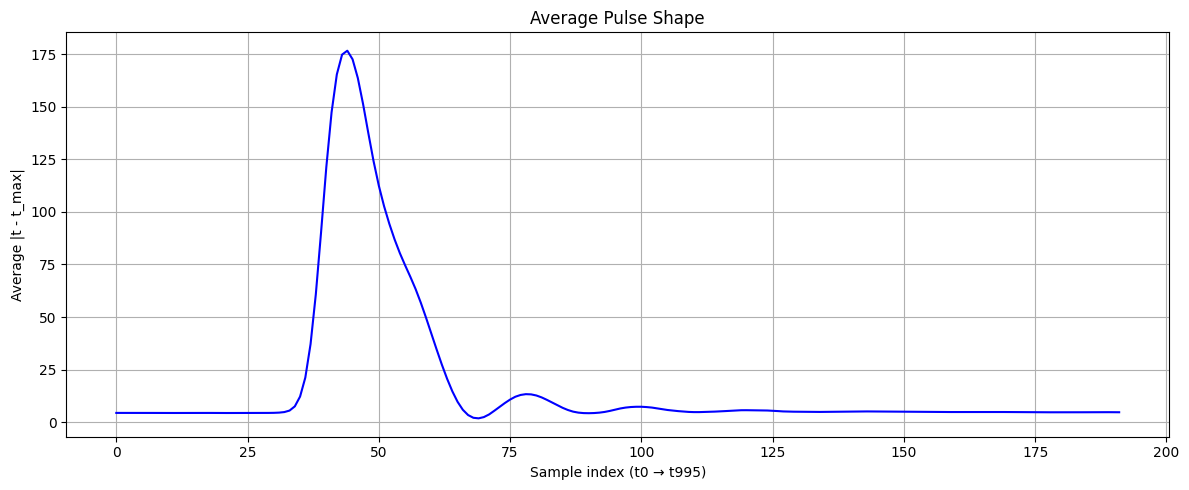

In [5]:
import matplotlib.pyplot as plt

# Select waveform columns
t_cols_1 = df_expanded_1.filter(regex=r'^t').columns
print(len(t_cols_1))
# Compute column-wise mean
mean_waveform_1 = df_expanded_1[t_cols_1].mean(axis=0).iloc[:-1]
print(len(mean_waveform_1))
# Plot
plt.figure(figsize=(12, 5))
plt.plot(range(len(t_cols_1)-1), mean_waveform_1, color='blue', linewidth=1.5)
plt.xlabel("Sample index (t0 → t995)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import csv

# List of file paths
file_paths = [
    "C:/Users/jayan/Downloads/21_08_25/21_08_25/BC501 A/Neutrons.csv"
   ]

parsed_data = []

# Loop through all files
for file_path in file_paths:
    with open(file_path, 'r') as f:
        csv_reader = csv.reader(f, delimiter=';')

        # Read header (skip, assuming all files have same header)
        header = next(csv_reader)

        # Read data rows
        for row in csv_reader:
            if not row:
                continue

            # First 6 columns fixed, rest are SAMPLES
            fixed_cols = row[:6]
            samples = row[6:]

            parsed_row = {
                'BOARD': fixed_cols[0],
                'CHANNEL': fixed_cols[1],
                'TIMETAG': fixed_cols[2],
                'ENERGY': fixed_cols[3],
                'ENERGYSHORT': fixed_cols[4],
                'FLAGS': fixed_cols[5],
                'SAMPLES': samples
            }
            parsed_data.append(parsed_row)

# Create initial DataFrame
df_2 = pd.DataFrame(parsed_data)

print("First 5 rows of the DataFrame:")
print(df_2.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code...

# Expand SAMPLES into separate columns t0, t1, ...
samples_df = pd.DataFrame(df_2['SAMPLES'].tolist())
samples_df = samples_df.add_prefix('t')

# Concatenate the new columns with the original DataFrame (excluding the old SAMPLES column)
df_expanded_2 = pd.concat([df_2.drop(columns=['SAMPLES']), samples_df], axis=1)

# print("First 5 rows with expanded SAMPLES columns:")
# print(df_expanded.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code... 
df_expanded_2.head()



First 5 rows of the DataFrame:
| BOARD   | CHANNEL   | TIMETAG      | ENERGY   | ENERGYSHORT   | FLAGS   | SAMPLES                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

,BOARD,CHANNEL,TIMETAG,ENERGY,ENERGYSHORT,FLAGS,t0,t1,t2,t3,...,t182,t183,t184,t185,t186,t187,t188,t189,t190,t191
0,0,0,76475630655,193,159,0x4000,877,875,875,877,...,875,875,875,875,877,876,877,876,875,876
1,0,0,118352434499,259,226,0x4000,875,876,879,880,...,873,872,876,876,876,875,874,872,873,874
2,0,0,136354874749,141,115,0x4000,878,878,877,877,...,875,875,875,877,876,876,875,875,874,875
3,0,0,360151145906,185,159,0x4000,876,878,878,877,...,874,874,876,876,876,876,875,875,874,875
4,0,0,511975307437,754,634,0x4000,876,877,879,879,...,875,876,876,876,874,875,874,875,875,874


In [7]:
# Select t-columns
t_cols_2 = df_expanded_2.filter(regex=r'^t').columns

# Ensure numeric (important)
df_expanded_2[t_cols_2] = df_expanded_2[t_cols_2].apply(pd.to_numeric, errors='coerce')

# Compute row-wise max
df_expanded_2["t_max"] = df_expanded_2[t_cols_2].max(axis=1)

# Subtract max from each t-value
df_expanded_2[t_cols_2] = df_expanded_2[t_cols_2].sub(df_expanded_2["t_max"], axis=0).abs()
df_expanded_2[t_cols_2]

C:\Users\jayan\AppData\Local\Temp\ipykernel_38180\1722737464.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_expanded_2["t_max"] = df_expanded_2[t_cols_2].max(axis=1)


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t182,t183,t184,t185,t186,t187,t188,t189,t190,t191
0,1,3,3,1,0,0,0,1,3,4,...,3,3,3,3,1,2,1,2,3,2
1,5,4,1,0,0,2,4,6,6,5,...,7,8,4,4,4,5,6,8,7,6
2,0,0,1,1,4,4,2,1,0,0,...,3,3,3,1,2,2,3,3,4,3
3,2,0,0,1,2,4,3,4,1,0,...,4,4,2,2,2,2,3,3,4,3
4,5,4,2,2,3,5,6,6,5,2,...,6,5,5,5,7,6,7,6,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91924,0,1,0,0,1,0,0,1,0,1,...,0,1,1,2,2,2,2,2,1,1
91925,3,3,3,2,0,0,1,1,3,4,...,4,4,4,3,3,2,2,3,3,3
91926,2,2,3,2,3,3,2,2,1,1,...,5,5,4,3,3,2,2,2,2,2
91927,2,3,3,1,0,0,0,1,3,3,...,5,5,2,1,0,2,5,6,7,5


In [8]:
mean_waveform_2 = df_expanded_2[t_cols_2].mean(axis=0)
mean_waveform_2

t0      1.862002
t1      1.853082
t2      1.827704
t3      1.792536
t4      1.774554
          ...   
t187    3.259146
t188    3.249181
t189    3.224837
t190    3.199545
t191    3.175799
Length: 192, dtype: float64

193
192


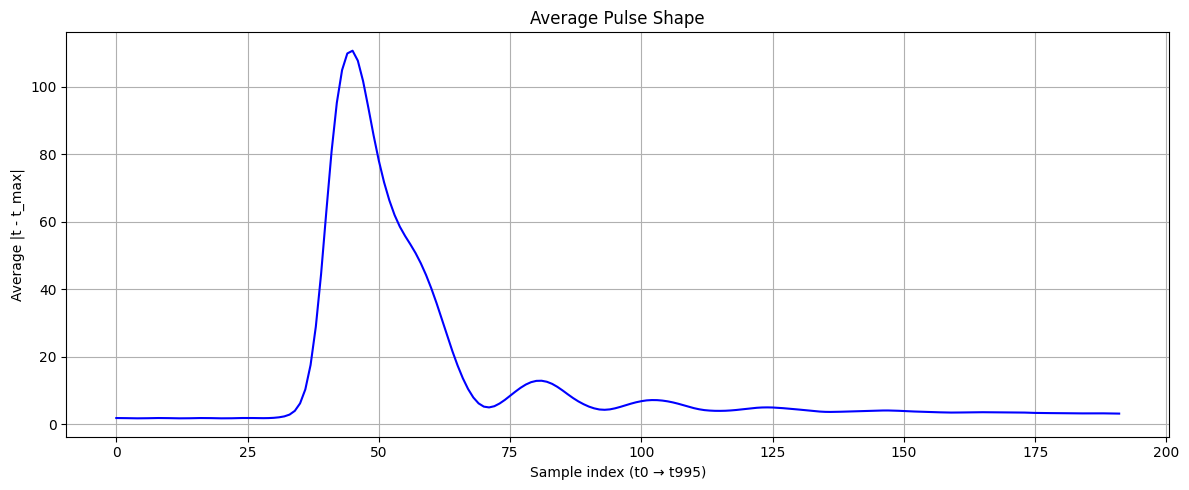

In [9]:
import matplotlib.pyplot as plt

# Select waveform columns
t_cols_2 = df_expanded_2.filter(regex=r'^t').columns
print(len(t_cols_2))
# Compute column-wise mean
mean_waveform_2 = df_expanded_2[t_cols_2].mean(axis=0).iloc[:-1]
print(len(mean_waveform_2))
# Plot
plt.figure(figsize=(12, 5))
plt.plot(range(len(t_cols_2)-1), mean_waveform_2, color='blue', linewidth=1.5)
plt.xlabel("Sample index (t0 → t995)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape")
plt.grid(True)
plt.tight_layout()
plt.show()


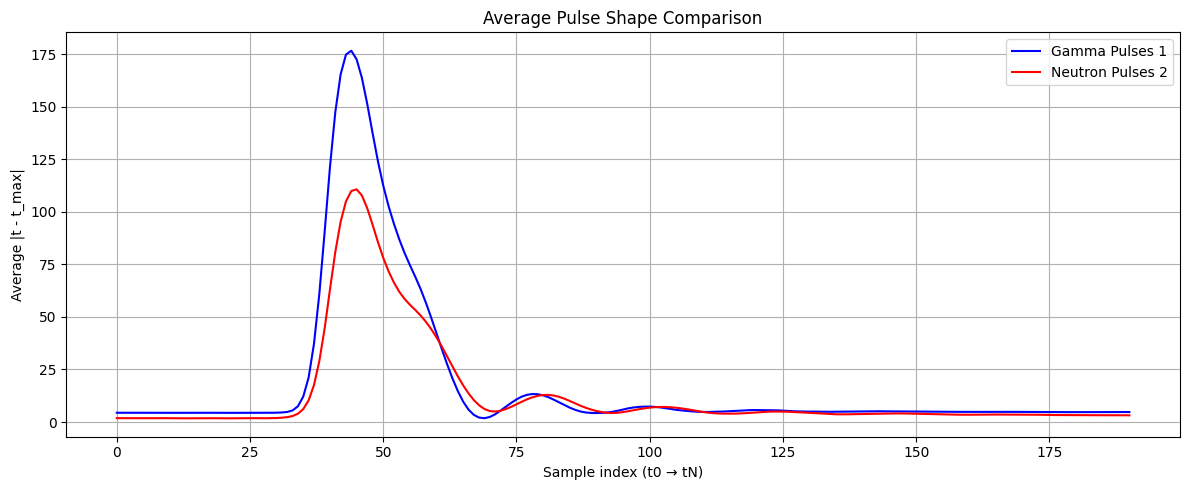

In [13]:
import matplotlib.pyplot as plt

# Select waveform columns
t_cols_1 = df_expanded_1.filter(regex=r'^t').columns
t_cols_2 = df_expanded_2.filter(regex=r'^t').columns

# Compute column-wise mean (drop last column if needed) Averaged
mean_waveform_1 = df_expanded_1[t_cols_1].mean(axis=0).iloc[:-1]
mean_waveform_2 = df_expanded_2[t_cols_2].mean(axis=0).iloc[:-1]


mean_waveform_1_norm = (mean_waveform_1 -mean_waveform_1.min()) / (mean_waveform_1.max() - mean_waveform_1.min())
mean_waveform_2_norm = (mean_waveform_2 -mean_waveform_2.min()) / (mean_waveform_2.max() - mean_waveform_2.min())

df_1_norm = df_expanded_1[t_cols_1].sub(
    df_expanded_1[t_cols_1].min(axis=1), axis=0
).div(
    df_expanded_1[t_cols_1].max(axis=1) - df_expanded_1[t_cols_1].min(axis=1),
    axis=0
)

df_2_norm = df_expanded_2[t_cols_2].sub(
    df_expanded_2[t_cols_2].min(axis=1), axis=0
).div(
    df_expanded_2[t_cols_2].max(axis=1) - df_expanded_2[t_cols_2].min(axis=1),
    axis=0
)

# Create x-axis (sample indices)
x1 = range(len(mean_waveform_1))
x2 = range(len(mean_waveform_2))

# Plot both on same figure
x = range(191)

plt.figure(figsize=(12, 5))
plt.plot(x, mean_waveform_1[0:191], color='blue', linewidth=1.5, label='Gamma Pulses 1')
plt.plot(x, mean_waveform_2[0:191], color='red', linewidth=1.5, label='Neutron Pulses 2')

plt.xlabel("Sample index (t0 → tN)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#plt.savefig("C:/Users/jayan/Downloads/21_08_25/21_08_25/Plots_Avg_n_Normalized/Averaged plots_Scintillator_2.png", dpi=300)  # Save as PNG with high resolution



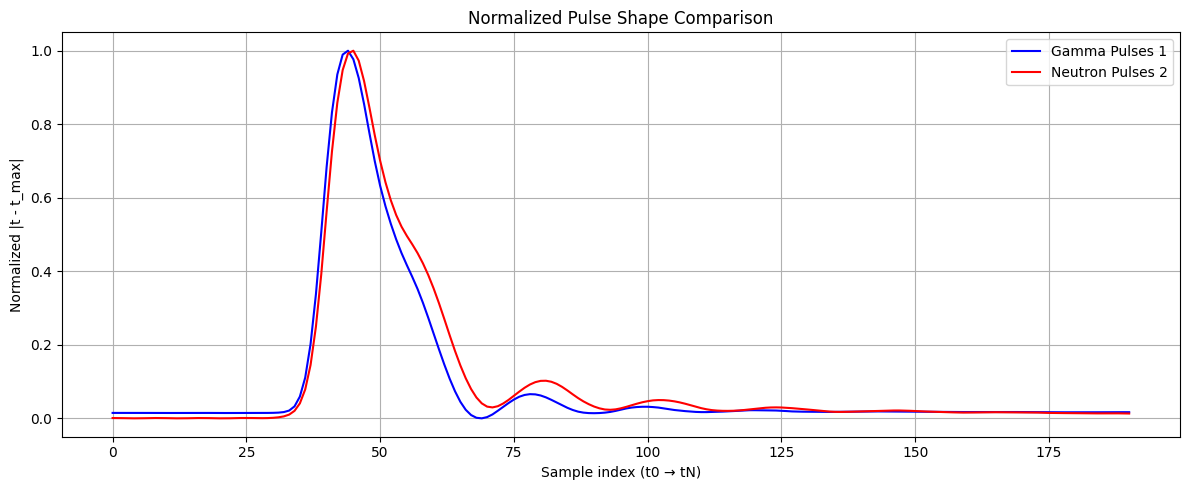

<Figure size 640x480 with 0 Axes>

In [14]:
# normalized
x = range(191)
plt.figure(figsize=(12, 5))
plt.plot(x, mean_waveform_1_norm[0:191], color='blue', linewidth=1.5, label='Gamma Pulses 1')
plt.plot(x, mean_waveform_2_norm[0:191], color='red', linewidth=1.5, label='Neutron Pulses 2')

plt.xlabel("Sample index (t0 → tN)")
plt.ylabel("Normalized |t - t_max|")
plt.title("Normalized Pulse Shape Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("C:/Users/jayan/Downloads/21_08_25/21_08_25/Plots_Avg_n_Normalized/Normalized plots_Scintillator_2.png", dpi=300)  # Save as PNG with high resolution


0.05628517823639774
0.1273885350318471
Split @ 60: Accuracy = 0.9674
Confusion Matrix:
 [[12095   451]
 [  556 17830]]
0.04066543438077632
0.10223144784639332
Split @ 61: Accuracy = 0.9759
Confusion Matrix:
 [[12202   344]
 [  403 17983]]
0.029250457038391214
0.08091603053435112
Split @ 62: Accuracy = 0.9823
Confusion Matrix:
 [[12297   249]
 [  297 18089]]
0.01992753623188405
0.062
Split @ 63: Accuracy = 0.9827
Confusion Matrix:
 [[12300   246]
 [  290 18096]]
0.012589928057553951
0.045275590551181105
Split @ 64: Accuracy = 0.9725
Confusion Matrix:
 [[12122   424]
 [  426 17960]]


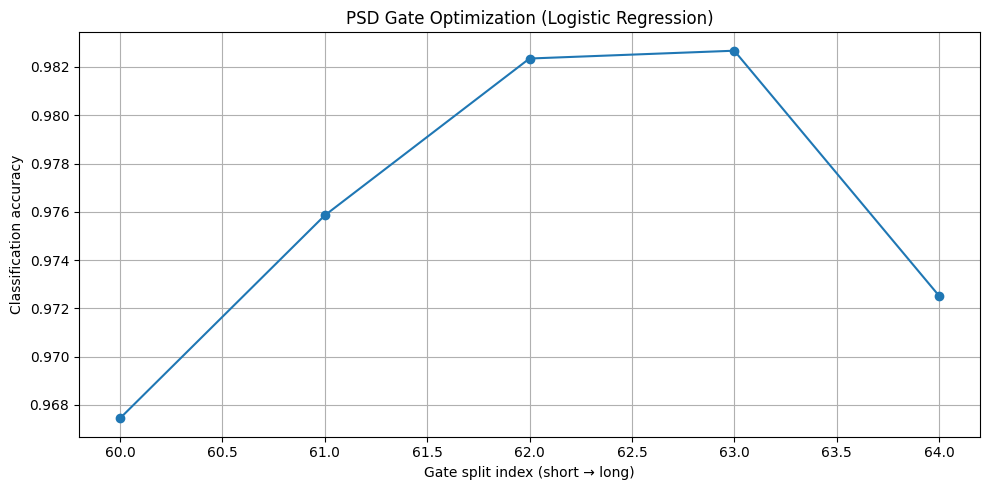

In [ ]:
#---------------------------------------------------Logistic regression---------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
# -------------------------------
# Gate sweep parameters
# -------------------------------
short_start = 30
long_end = 75
splits = range(60, 65, 1)   # 50, 55, 60, ..., 100

accuracies = []
conf_matrices = []
split_record = []

# -------------------------------
# Loop over split positions
# -------------------------------
for split in splits:
    # ---- Gamma ratios ----
    gamma_short = df_1_norm.iloc[:, short_start:split].sum(axis=1)
    gamma_long  = df_1_norm.iloc[:, split:long_end].sum(axis=1)
    gamma_ratio = 1/(gamma_short / gamma_long)
    print(gamma_ratio[1])
    # ---- Neutron ratios ----
    neutron_short = df_2_norm.iloc[:, short_start:split].sum(axis=1)
    neutron_long  = df_2_norm.iloc[:, split:long_end].sum(axis=1)
    neutron_ratio = 1/(neutron_short / neutron_long)
    print(neutron_ratio[1])

    # ---- Dataset ----
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([
        np.zeros(len(gamma_ratio)),   # gamma = 0
        np.ones(len(neutron_ratio))   # neutron = 1
    ])

    # ---- Train / test split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=41
    )

    # ---- Logistic Regression ----
    clf = LogisticRegression()
    clf.fit(X_train, y_train)

    # ---- Accuracy ----
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Split @ {split}: Accuracy = {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    split_record.append(split)



# -------------------------------
# Plot accuracy vs gate split
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(splits, accuracies, marker='o')
plt.xlabel("Gate split index (short → long)")
plt.ylabel("Classification accuracy")
plt.title("PSD Gate Optimization (Logistic Regression)")
plt.grid(True)
plt.tight_layout()
plt.show()
